# 1D Gouy-Chapman-Stern (GCS) Model

This notebook computes the analytical **Gouy-Chapman-Stern** solution for a symmetric (z:z) electrolyte in 1D.

## Model

The GCS model splits the electric double layer into two regions:

1. **Stern (compact) layer** — a charge-free region of thickness $d$ between the electrode surface and the outer Helmholtz plane (OHP), with a low dielectric constant $\varepsilon_s$. The potential drops linearly:

$$
\phi(x) = \phi_0 - \frac{\sigma}{\varepsilon_s}\,x, \qquad 0 \le x \le d
$$

2. **Diffuse layer** — governed by the non-linear Poisson-Boltzmann equation beyond the OHP:

$$
\phi(x) = \frac{4\,k_BT}{ze}\,\mathrm{arctanh}\!\left[\tanh\!\left(\frac{ze\,\phi_d}{4\,k_BT}\right)\exp\!\left(-\frac{x-d}{\lambda_D}\right)\right], \qquad x > d
$$

### Boundary condition at the OHP

At $x = d$, the surface charge density must be continuous across the two regions (charge matching):

$$
\sigma_{\text{Stern}} = \frac{\varepsilon_s}{d}(\phi_d - \phi_0) = \sqrt{8\,\varepsilon_\text{GC}\,k_BT\,c_0\,N_A}\;\sinh\!\left(\frac{ze\,\phi_d}{2\,k_BT}\right) = \sigma_{\text{diffuse}}
$$

Note that the **electric field is discontinuous** at the OHP because the dielectric constants differ between the compact layer ($\varepsilon_H$) and the diffuse layer ($\varepsilon_\text{GC}$). The normal displacement field $D = \varepsilon E$ is continuous, but since $\varepsilon_H \neq \varepsilon_\text{GC}$, the electric field $E$ jumps at $x = d$.

Robin boundary condition at the OHP:
$$
\frac{\varepsilon_H}{d}(\phi_d - \phi_0) = \varepsilon_\text{GC}\frac{d \phi}{dx}\bigg|_{x=d}
$$

## When to use this notebook

- Systems where the compact (Stern) layer significantly affects the potential distribution
- Moderate to high surface potentials where linear PB is insufficient
- Validation of numerical solvers against the closed-form GCS solution

## What to check in results

- Linear potential drop inside the Stern layer ($0 \le x \le d$)
- Kink in the potential profile at the OHP — the potential is continuous but its derivative (the E-field) is not, due to the dielectric difference
- Zero ion concentration inside the Stern layer
- Charge balance between surface charge and diffuse-layer screening

In [1]:
import unxt
import quaxed.numpy as jnp

import matplotlib.pyplot as plt

In [2]:
from fdm_edl.api import ElectricalDoubleLayer
from fdm_edl.utils.bc import BoundaryCondition

from fdm_edl.benchmark import GCSModel

In [3]:
# 0.01 M 2-2 electrolyte, T = 298 K, epsilon_r = 78.5
edl_obj = ElectricalDoubleLayer("input.json")
n_grid = 500
_x = unxt.Quantity(jnp.linspace(0.0, 20.0, n_grid), unit="nm")
# sigma = _constants.ELEMENTARY_CHARGE / unxt.Quantity(1e4, "angstrom^2")
phi_0 = unxt.Quantity(0.025, "V")
d_ohp = unxt.Quantity(5, "Angstrom")
eps_ohp = 6.0

In [4]:
non_linear_pb = GCSModel(edl_obj=edl_obj, d_ohp=d_ohp, eps_ohp=eps_ohp)
non_linear_pb.compute(x=_x, phi_0=phi_0)

In [5]:
# Robin BC: phi(0) = phi_0; Neumann BC: dphi/dx(L) = 0
boundary_conditions = [
    BoundaryCondition(
        1.0,
        -(edl_obj.electrolyte.epsilon_r / eps_ohp) * d_ohp,
        -phi_0,
        [0],
    ),
    BoundaryCondition(
        0.0,
        1.0,
        unxt.Quantity(0.0, unit=phi_0.unit),
        [n_grid - 1],
    ),
]
# shift the boundary of coordinates to the OHP
x = (_x + d_ohp).to("nm")
edl_obj.compute(x, boundary_conditions)

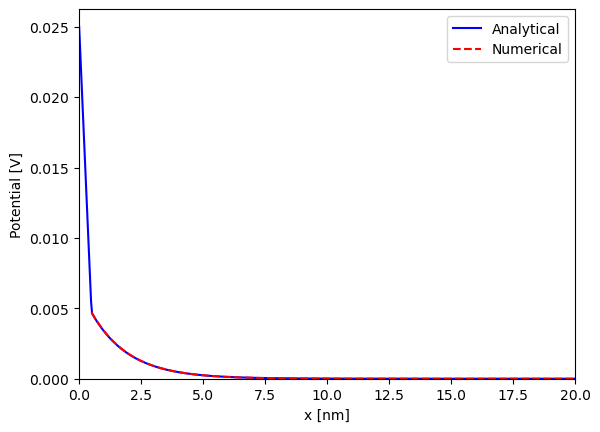

In [6]:
fig, ax = plt.subplots()

# potential in V
ax.plot(
    _x.to("nm"), non_linear_pb.edl_status.phi.to("V"), color="blue", label="Analytical"
)
ax.plot(
    edl_obj.result.coordinate.to("nm"),
    edl_obj.result.phi.to("V"),
    color="red",
    linestyle="dashed",
    label="Numerical",
)
ax.legend()

ax.set_xlim(0, 20)
ax.set_ylim(bottom=0.0)
ax.set_xlabel("x [nm]")
ax.set_ylabel("Potential [V]")

plt.show()

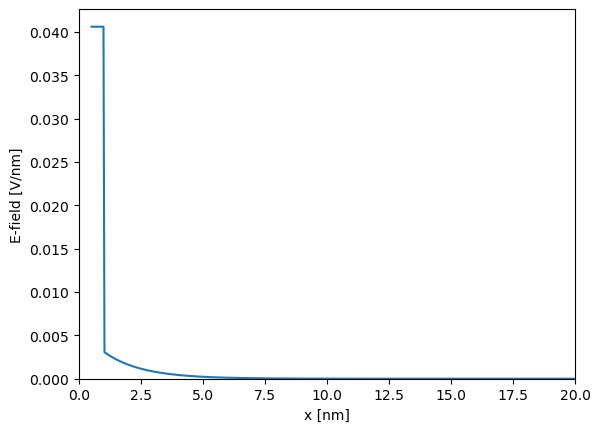

In [7]:
fig, ax = plt.subplots()

ax.plot(x.to("nm"), non_linear_pb.edl_status.efield.to("V/nm"))

ax.set_xlim(0, 20)
ax.set_ylim(bottom=0.0)
ax.set_xlabel("x [nm]")
ax.set_ylabel("E-field [V/nm]")

plt.show()

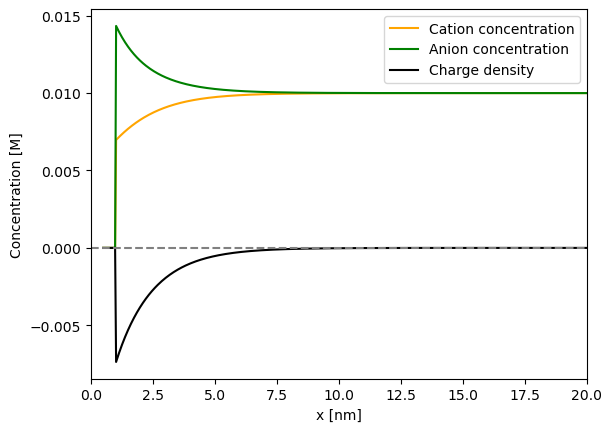

In [8]:
fig, ax = plt.subplots()

# ion conc in mol/L
c_cation = non_linear_pb.edl_status.ion_conc["Ca"]
c_anion = non_linear_pb.edl_status.ion_conc["SO4"]

ax.plot(x.to("nm"), c_cation, color="orange", label="Cation concentration")
ax.plot(x.to("nm"), c_anion, color="green", label="Anion concentration")
ax.plot(x.to("nm"), c_cation - c_anion, color="k", label="Charge density")

ax.axhline(0.0, color="gray", linestyle="dashed")

ax.set_xlim(0, 20)
ax.set_xlabel("x [nm]")
ax.set_ylabel("Concentration [M]")
ax.legend()

plt.show()